## Bitcoin Prediction System

# Bitcoin Price Prediction using Machine Learning

This project demonstrates an end-to-end machine learning pipeline for predicting
Bitcoin prices. Historical price data is used to train a machine learning model,
and live Bitcoin prices are fetched using an external API to generate future
price predictions.

The project focuses on real-world ML workflow rather than perfect accuracy.

In [23]:
import requests

url = "https://api.coingecko.com/api/v3/simple/price"
params = {
    "ids": "bitcoin",
    "vs_currencies": "usd"
}

response = requests.get(url, params=params)
data = response.json()

data


{'bitcoin': {'usd': 81897}}

In [24]:
btc_price = data['bitcoin']['usd']
print("Current Bitcoin Price (USD):", btc_price)


Current Bitcoin Price (USD): 81897


## Live Bitcoin Price Using API

In this project, live Bitcoin price data is fetched using the CoinGecko API.
An API allows programs to communicate with external servers and retrieve
real-time data. The current Bitcoin price in USD is obtained and later used
as input for the prediction system.


In [25]:
import yfinance as yf

btc = yf.download("BTC-USD", start="2017-01-01", end="2024-01-01")
btc.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2017-01-01,998.325012,1003.080017,958.698975,963.658020,147775008
2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992
2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000
2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984
2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008


In [26]:
btc['Close']


Ticker,BTC-USD
Date,
2017-01-01,998.325012
2017-01-02,1021.750000
2017-01-03,1043.839966
2017-01-04,1154.729980
2017-01-05,1013.380005
...,...
2023-12-27,43442.855469
2023-12-28,42627.855469
2023-12-29,42099.402344


In [27]:
btc['Tomorrow'] = btc['Close'].shift(-1)
btc.head()


Price,Close,High,Low,Open,Volume,Tomorrow
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,
Date,,,,,,
2017-01-01,998.325012,1003.080017,958.698975,963.658020,147775008,1021.750000
2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992,1043.839966
2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000,1154.729980
2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984,1013.380005
2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008,902.200989


In [28]:
btc.dropna(inplace=True)


In [29]:
X = btc[['Close']]      # what model sees
y = btc['Tomorrow']    # what model predicts


In [30]:
split = int(len(btc) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


In [31]:
y_pred = model.predict(X_test)


In [37]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions on test data
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")


Model Evaluation Metrics
------------------------
Mean Absolute Error (MAE): 1463.41
Root Mean Squared Error (RMSE): 2012.95
R2 Score: 0.9894


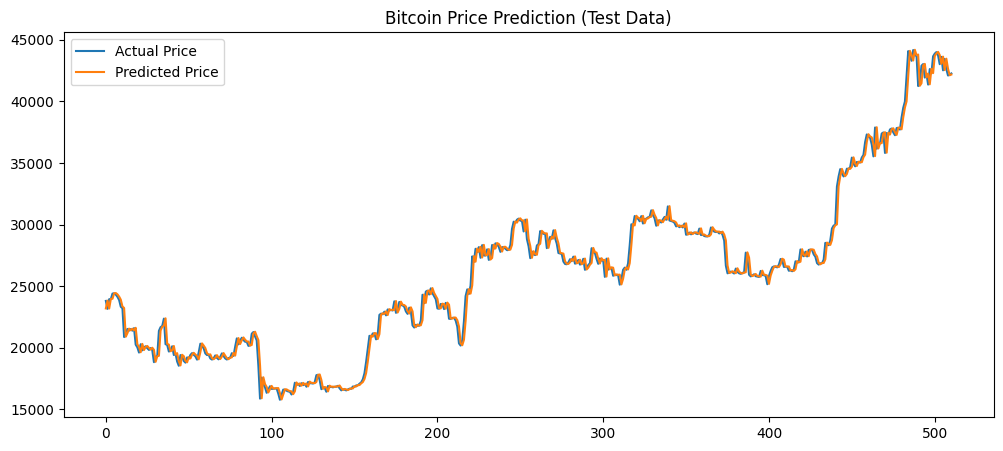

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.legend()
plt.title("Bitcoin Price Prediction (Test Data)")
plt.show()


In [34]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
# CLEAN, FINAL, GUARANTEED-WORKING PIPELINE

import yfinance as yf
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Download data
btc = yf.download("BTC-USD", start="2017-01-01")

# 2. Keep only Close price
btc = btc[['Close']]

# 3. Create target (tomorrow's price)
btc['Tomorrow'] = btc['Close'].shift(-1)

# 4. Drop NaN
btc = btc.dropna()

# 5. Prepare X and y
X = btc[['Close']]
y = btc['Tomorrow']

# 6. Time-based split
split = int(len(btc) * 0.8)

X_train = X.iloc[:split]
y_train = y.iloc[:split]

X_test = X.iloc[split:]
y_test = y.iloc[split:]

# 7. Train model
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained successfully")
print("Training samples:", len(X_train))


[*********************100%***********************]  1 of 1 completed

✅ Model trained successfully
Training samples: 2653


In [36]:
import requests
import numpy as np

def get_live_bitcoin_price():
    url = "https://api.coingecko.com/api/v3/simple/price"
    params = {"ids": "bitcoin", "vs_currencies": "usd"}
    return requests.get(url, params=params).json()['bitcoin']['usd']

current_price = get_live_bitcoin_price()
prediction = model.predict(np.array([[current_price]]))[0]

print("===================================")
print(" BITCOIN PRICE PREDICTION SYSTEM ")
print("===================================")
print(f"Current Price   : ${current_price:,.2f}")
print(f"Predicted Price : ${prediction:,.2f}")
print("===================================")


 BITCOIN PRICE PREDICTION SYSTEM 
Current Price   : $81,897.00
Predicted Price : $81,907.01


## Conclusion

In this project, a machine learning model was trained using historical Bitcoin
price data and integrated with a live API to predict future prices. This project
helped in understanding real-world challenges such as volatile data, API usage,
and building complete ML systems.

Future improvements may include using more advanced models and additional
market indicators.
